# Data Quality Assessment

## Titanic Dataset

Data quality assessment is the process of examining a dataset to identify problems that may affect analysis or Machine Learning models.

In this notebook, we will investigate:

- Missing values
- Missing value percentages
- Missing value patterns
- Duplicate records
- Completely duplicated rows
- Potential duplicate records
- Invalid or impossible values
- Incorrect categories
- Incorrect data types
- Empty strings and null-like values

The purpose is to understand the quality of the Titanic dataset before performing further data analysis or Machine Learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 1. Missing Values

## Concept

Missing values occur when information is not available for a particular observation. In a dataset, missing values are commonly represented as `NaN`, `None`, or empty values.

## Example

For example, a passenger's age may not have been recorded:

Age = NaN

This means the actual age is unknown.

## Implementation

We will count the missing values in each column of the Titanic dataset.

## Output

The result will show the number of missing values present in every column.

## Interpretation

Columns with a higher number of missing values may require special attention during data cleaning.

## Insight

Missing values can affect statistical analysis and Machine Learning models if they are not handled properly.

## AI/ML Relevance

Many Machine Learning algorithms cannot directly handle missing values. Therefore, we may need to remove, replace, or impute missing values before training a model.

In [2]:
missing_values = df.isnull().sum()

print("Missing Values by Column:")
print(missing_values)

Missing Values by Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# 2. Percentage of Missing Values

## Concept

The percentage of missing values helps us understand how serious the missing data problem is in each column.

## Example

If a column contains 100 records and 20 values are missing, then the missing value percentage is 20%.

## Implementation

We will calculate the percentage of missing values for each column.

## Output

The result will show the proportion of missing data in percentage form.

## Interpretation

A high missing value percentage may indicate that a column requires imputation or may be unsuitable for direct use in analysis.

## Insight

The percentage is often more informative than the raw number of missing values because it considers the total size of the dataset.

## AI/ML Relevance

Before building a Machine Learning model, missing value percentages help us decide whether to retain, clean, impute, or remove a feature.

In [3]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Value Percentage:")
print(missing_percentage.round(2))

Missing Value Percentage:
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


# 3. Missing Values Summary

## Concept

A missing values summary combines the number and percentage of missing values into one table.

## Example

A column may have:

- Missing Values: 177
- Missing Percentage: 19.87%

This provides a clearer overview of data quality.

## Implementation

We will create a summary table containing both the missing value count and missing percentage.

## Output

The output will provide a structured missing data report.

## Interpretation

This makes it easier to compare columns and identify which variables have the most missing information.

## Insight

In the Titanic dataset, columns such as `Age`, `Cabin`, and `Embarked` may contain missing values.

## AI/ML Relevance

A summary table helps determine the appropriate data preprocessing strategy before model development.

In [4]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

print(missing_summary)

             Missing Values  Missing Percentage
PassengerId               0                0.00
Survived                  0                0.00
Pclass                    0                0.00
Name                      0                0.00
Sex                       0                0.00
Age                     177               19.87
SibSp                     0                0.00
Parch                     0                0.00
Ticket                    0                0.00
Fare                      0                0.00
Cabin                   687               77.10
Embarked                  2                0.22


# 4. Missing Value Patterns

## Concept

Missing value patterns help us understand whether missing data occurs randomly or appears repeatedly in specific columns.

## Example

If many passengers have missing cabin information while other columns are complete, the missingness is concentrated in the `Cabin` column.

## Implementation

We will visualize missing values using a heatmap.

## Output

Missing values will be visually displayed across the dataset.

## Interpretation

The visualization helps us quickly identify columns with large amounts of missing information.

## Insight

Patterns in missing data may provide useful information about how the dataset was originally collected.

## AI/ML Relevance

Understanding missing patterns helps us choose better strategies for handling missing data and avoiding biased model results.

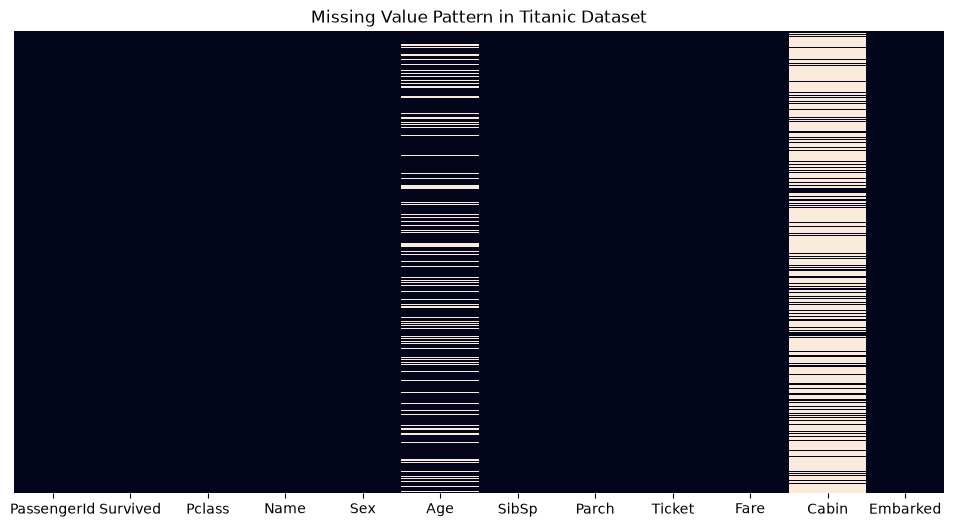

In [5]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Value Pattern in Titanic Dataset")
plt.show()

# 5. Duplicate Records

## Concept

A duplicate record is a row that appears more than once in a dataset.

## Example

If the same passenger information is entered twice with exactly the same values, one of the rows may be a duplicate.

## Implementation

We will identify and count completely duplicated rows.

## Output

The result will show the total number of exact duplicate records.

## Interpretation

A large number of duplicate records may indicate repeated data entry or data collection problems.

## Insight

Exact duplicates should be reviewed before removal because duplicate records may sometimes represent valid repeated observations.

## AI/ML Relevance

Duplicate records can bias a Machine Learning model by giving repeated observations more influence than they should have.

In [6]:
duplicate_count = df.duplicated().sum()

print("Number of Completely Duplicated Rows:", duplicate_count)

Number of Completely Duplicated Rows: 0


# 6. Completely Duplicated Rows

## Concept

After counting duplicate records, it is useful to display them and inspect the actual rows.

## Example

Two rows are considered completely duplicated when every value in both rows is identical.

## Implementation

We will display all rows that are completely duplicated.

## Output

The output will show the duplicate records, if any exist.

## Interpretation

If no rows are displayed, there are no completely duplicated records in the dataset.

## Insight

Inspecting duplicate rows before removing them is a good data quality practice.

## AI/ML Relevance

Removing unnecessary duplicate records can improve the quality and reliability of a Machine Learning dataset.

In [7]:
complete_duplicates = df[df.duplicated(keep=False)]

print("Completely Duplicated Rows:")
display(complete_duplicates)

Completely Duplicated Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


# 7. Potential Duplicate Records

## Concept

Potential duplicates are records that may refer to the same observation but are not completely identical.

## Example

Two passenger records may have the same name, ticket number, and other information but different identifiers.

## Implementation

We will check for records that have the same passenger details while excluding the unique identifier column `PassengerId`.

## Output

The output will show records that appear similar and may require manual review.

## Interpretation

Potential duplicates are not automatically considered errors. They should be examined carefully before any action is taken.

## Insight

Some similar records may represent family members or passengers travelling together, especially when they share a ticket.

## AI/ML Relevance

Potential duplicate records can create data leakage or bias if the same observation is effectively represented multiple times.

In [8]:
comparison_columns = [
    "Survived", "Pclass", "Name", "Sex", "Age",
    "SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked"
]

potential_duplicates = df[
    df.duplicated(subset=comparison_columns, keep=False)
]

print("Potential Duplicate Records:")
display(potential_duplicates)

Potential Duplicate Records:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


# 8. Negative Values

## Concept

Some numerical variables should never contain negative values.

## Example

A passenger cannot have:

- Negative age
- Negative fare
- Negative number of siblings
- Negative number of parents or children

## Implementation

We will check important numerical columns for negative values.

## Output

The result will show the number of negative values in each selected column.

## Interpretation

Any negative value found in these columns would be considered suspicious and should be investigated.

## Insight

Checking numerical ranges helps identify possible data-entry errors.

## AI/ML Relevance

Invalid numerical values can negatively affect model training and produce unreliable predictions.

In [9]:
columns_to_check = ["Age", "SibSp", "Parch", "Fare"]

negative_values = {}

for column in columns_to_check:
    negative_values[column] = (df[column] < 0).sum()

print("Negative Values:")
print(negative_values)

Negative Values:
{'Age': np.int64(0), 'SibSp': np.int64(0), 'Parch': np.int64(0), 'Fare': np.int64(0)}


# 9. Impossible Values

## Concept

Impossible values are values that do not make logical sense based on the meaning of a variable.

## Example

For the Titanic dataset:

- Age should not be negative.
- Passenger class should only be 1, 2, or 3.
- Survived should contain only 0 or 1.

## Implementation

We will check selected columns against their expected valid ranges or categories.

## Output

The output will show records containing potentially impossible values.

## Interpretation

If no invalid records are found, the selected variables satisfy the expected basic rules.

## Insight

Logical validation helps detect errors that may not be identified through missing value or duplicate checks.

## AI/ML Relevance

Machine Learning models assume that input data represents meaningful information. Impossible values can reduce model quality.

In [10]:
invalid_pclass = df[~df["Pclass"].isin([1, 2, 3])]
invalid_survived = df[~df["Survived"].isin([0, 1])]
invalid_age = df[(df["Age"] < 0) | (df["Age"] > 100)]

print("Invalid Pclass Records:", len(invalid_pclass))
print("Invalid Survived Records:", len(invalid_survived))
print("Invalid Age Records:", len(invalid_age))

Invalid Pclass Records: 0
Invalid Survived Records: 0
Invalid Age Records: 0


# 10. Incorrect Categories

## Concept

Categorical columns should contain meaningful and expected categories.

## Example

The `Sex` column in the Titanic dataset is expected to contain values such as:

- male
- female

The `Embarked` column is expected to contain the known embarkation categories.

## Implementation

We will display the unique values in important categorical columns.

## Output

The output will show all available categories.

## Interpretation

Unexpected categories may indicate spelling mistakes, inconsistent data entry, or data quality problems.

## Insight

Reviewing unique categories helps us identify inconsistencies before encoding categorical variables.

## AI/ML Relevance

Incorrect or inconsistent categories can create unnecessary categories during encoding and negatively affect model performance.

In [11]:
categorical_columns = ["Sex", "Embarked", "Pclass", "Survived"]

for column in categorical_columns:
    print(f"\nUnique values in {column}:")
    print(df[column].unique())


Unique values in Sex:
<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

Unique values in Embarked:
<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

Unique values in Pclass:
[3 1 2]

Unique values in Survived:
[0 1]


# 11. Incorrect Data Types

## Concept

Each column should have an appropriate data type based on the type of information it represents.

## Example

- `Age` should be numerical.
- `Fare` should be numerical.
- `Name` should be text.
- `Embarked` should be categorical or text.

## Implementation

We will inspect the data types of all Titanic dataset columns.

## Output

The output will display the current data type of every column.

## Interpretation

A data type that does not match the meaning of a variable may require conversion.

## Insight

Correct data types make analysis easier and help prevent errors during calculations.

## AI/ML Relevance

Correct data types are essential for preprocessing, feature engineering, encoding, and Machine Learning model preparation.

In [12]:
print("Data Types:")
print(df.dtypes)

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


# 12. Empty Strings

## Concept

An empty string is a value that contains no visible information but may not be recognized by Pandas as a missing value.

## Example

A value such as:

""

is different from a standard `NaN` value.

## Implementation

We will count empty strings in text-based columns.

## Output

The result will show whether any empty strings exist in the dataset.

## Interpretation

Empty strings should be considered during data cleaning because they may represent missing information.

## Insight

Checking only `NaN` values is not always enough for a complete data quality assessment.

## AI/ML Relevance

Unrecognized empty strings can cause problems during encoding and missing value preprocessing.

In [13]:
string_columns = df.select_dtypes(include=["object", "string"]).columns

empty_string_count = {}

for column in string_columns:
    empty_string_count[column] = (
        df[column].astype("string").str.strip().eq("").sum()
    )

print("Empty Strings by Column:")
print(empty_string_count)

Empty Strings by Column:
{'Name': 0, 'Sex': 0, 'Ticket': 0, 'Cabin': 0, 'Embarked': 0}


# 13. Null-Like Values

## Concept

Null-like values are text values that may represent missing information but are not stored as actual `NaN` values.

## Example

Common null-like values include:

- NA
- N/A
- None
- null
- unknown
- -

## Implementation

We will search text columns for common null-like values.

## Output

The output will show whether these values are present.

## Interpretation

Null-like values should be standardized to actual missing values during data cleaning.

## Insight

Different representations of missing data can make a dataset inconsistent.

## AI/ML Relevance

Standardizing missing values is important before applying imputation or other preprocessing techniques.

In [14]:
null_like_values = ["NA", "N/A", "None", "null", "NULL", "unknown", "-"]

null_like_results = {}

for column in string_columns:
    null_like_results[column] = df[column].isin(null_like_values).sum()

print("Null-Like Values by Column:")
print(null_like_results)

Null-Like Values by Column:
{'Name': np.int64(0), 'Sex': np.int64(0), 'Ticket': np.int64(0), 'Cabin': np.int64(0), 'Embarked': np.int64(0)}


# 14. Unexpected Values

## Concept

Unexpected values are values that fall outside the normal or expected range of a variable.

## Example

For the Titanic dataset:

- An extremely high age may need review.
- An unusual fare may need investigation.
- An unexpected category may indicate inconsistent data.

## Implementation

We will review descriptive statistics for important numerical columns.

## Output

The output will show minimum, maximum, average, and other statistical measures.

## Interpretation

Extreme values are not automatically errors. They should be reviewed to determine whether they are valid observations or possible data-entry problems.

## Insight

Unexpected values may represent outliers, rare observations, or data quality issues.

## AI/ML Relevance

Extreme or incorrect values can influence statistical models and may require special treatment during preprocessing.

In [15]:
print(df[["Age", "SibSp", "Parch", "Fare"]].describe())

              Age       SibSp       Parch        Fare
count  714.000000  891.000000  891.000000  891.000000
mean    29.699118    0.523008    0.381594   32.204208
std     14.526497    1.102743    0.806057   49.693429
min      0.420000    0.000000    0.000000    0.000000
25%     20.125000    0.000000    0.000000    7.910400
50%     28.000000    0.000000    0.000000   14.454200
75%     38.000000    1.000000    0.000000   31.000000
max     80.000000    8.000000    6.000000  512.329200


# 15. Overall Data Quality Summary

## Concept

After investigating individual data quality issues, we can summarize the overall condition of the dataset.

## Example

A dataset may contain missing values but no duplicate records. In this situation, missing data handling becomes the primary preprocessing task.

## Implementation

We will summarize the major findings from the data quality assessment.

## Output

The output will provide a quick overview of missing values, duplicates, and empty strings.

## Interpretation

The summary helps identify which data quality problems should be addressed first.

## Insight

For the Titanic dataset, missing values are expected to be one of the most important data quality concerns, especially in columns such as `Age` and `Cabin`.

## AI/ML Relevance

A good understanding of data quality is essential before feature engineering, model training, and model evaluation.

In [16]:
print("===== DATA QUALITY SUMMARY =====")

print("\n1. Dataset Shape:")
print(df.shape)

print("\n2. Total Missing Values:")
print(df.isnull().sum().sum())

print("\n3. Missing Values by Column:")
print(df.isnull().sum())

print("\n4. Completely Duplicated Rows:")
print(df.duplicated().sum())

print("\n5. Empty Strings:")
print(sum(
    df[column].astype("string").str.strip().eq("").sum()
    for column in string_columns
))

===== DATA QUALITY SUMMARY =====

1. Dataset Shape:
(891, 12)

2. Total Missing Values:
866

3. Missing Values by Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

4. Completely Duplicated Rows:
0

5. Empty Strings:
0


# Conclusion

The data quality assessment helped us examine the Titanic dataset before performing further analysis or Machine Learning.

The main areas investigated were:

- Missing values and their percentages
- Missing value patterns
- Completely duplicated records
- Potential duplicate records
- Negative and impossible values
- Incorrect categories
- Incorrect data types
- Empty strings
- Null-like values
- Unexpected values

The assessment shows that data cleaning should be performed carefully before building a Machine Learning model. Missing values, especially in important columns, need appropriate treatment. Duplicate and invalid records should also be reviewed rather than automatically removed.

## Final Insight

Data quality assessment is an essential step in the data analysis workflow. A Machine Learning model can only learn from the information provided to it, so poor-quality data may lead to poor-quality predictions.

Therefore, understanding and improving data quality before model development is necessary for building reliable and meaningful Machine Learning solutions.